# LoCoMotif Basics with Visual Intuition

*Understanding variable-length and time-warped motif discovery before regime-conditioned benchmarking*


## 1. Purpose of this notebook

Matrix Profile finds fixed-length nearest-neighbor subsequences. This makes it a strong, interpretable baseline: choose a window length `m`, scan the series, and identify subsequences that have unusually close matches.

LoCoMotif targets a different problem. It is designed to find coherent motif sets that may vary in length and speed. That matters in financial time series because the same market structure can appear compressed during intense volatility and stretched during calmer trading.

In the thesis context, financial markets are nonstationary: volatility regimes change the meaning of similarity. The broader benchmark compares LoCoMotif against Matrix Profile under both regime-agnostic and regime-conditioned settings, including volatility-quantile regimes and HMM regimes. This notebook builds intuition before running the comparison.


## 2. Environment and path setup

This section defines project paths, creates the report directory, imports the required libraries, and checks optional motif-discovery packages. Missing optional packages are reported without stopping execution.


In [1]:
from pathlib import Path
import json
import time
import warnings
import importlib
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.simplefilter("default")

plt.rcParams.update({
    "figure.figsize": (11, 4.8),
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "font.size": 10,
})


def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def find_project_root():
    known_root = Path(r"C:\Users\learn\OneDrive\Desktop\Final Masters Thesis")
    candidates = [Path.cwd(), *Path.cwd().parents, known_root]
    seen = set()
    for candidate in candidates:
        key = str(candidate).lower()
        if key in seen:
            continue
        seen.add(key)
        if (candidate / "final_dataset").exists():
            return candidate
    return known_root if known_root.exists() else Path.cwd()


PROJECT_ROOT = find_project_root()
FINAL_DATASET_DIR = PROJECT_ROOT / "final_dataset"
REPORT_DIR = ensure_dir(PROJECT_ROOT / "reports" / "locomotif_initial_study")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"FINAL_DATASET_DIR: {FINAL_DATASET_DIR}")
print(f"REPORT_DIR: {REPORT_DIR}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

try:
    import stumpy
    STUMPY_AVAILABLE = True
    STUMPY_IMPORT_ERROR = None
except Exception as exc:
    stumpy = None
    STUMPY_AVAILABLE = False
    STUMPY_IMPORT_ERROR = repr(exc)

LOCOMOTIF_MODULE = None
LOCOMOTIF_MODULE_NAME = None
LOCOMOTIF_IMPORT_ERROR = {}
for module_name in ["locomotif.locomotif", "locomotif", "LoCoMotif", "loco_motif", "locomotif_py"]:
    try:
        LOCOMOTIF_MODULE = importlib.import_module(module_name)
        LOCOMOTIF_MODULE_NAME = module_name
        break
    except Exception as exc:
        LOCOMOTIF_IMPORT_ERROR[module_name] = repr(exc)

LOCOMOTIF_AVAILABLE = LOCOMOTIF_MODULE is not None

print(f"stumpy available: {STUMPY_AVAILABLE}")
if not STUMPY_AVAILABLE:
    print(f"stumpy import issue: {STUMPY_IMPORT_ERROR}")
print(f"LoCoMotif package available: {LOCOMOTIF_AVAILABLE}")
if LOCOMOTIF_AVAILABLE:
    print(f"LoCoMotif module name: {LOCOMOTIF_MODULE_NAME}")
    print(f"LoCoMotif apply_locomotif available: {hasattr(LOCOMOTIF_MODULE, 'apply_locomotif')}")
else:
    print("LoCoMotif was not found under common module names. Placeholder sections will stay runnable.")


PROJECT_ROOT: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis
FINAL_DATASET_DIR: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\final_dataset
REPORT_DIR: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study
pandas: 3.0.3
numpy: 2.4.6


stumpy available: True
LoCoMotif package available: True
LoCoMotif module name: locomotif.locomotif
LoCoMotif apply_locomotif available: True


In [2]:
def load_parquet_with_timestamp(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing parquet file: {path}")

    df = pd.read_parquet(path).copy()
    timestamp_candidates = ["timestamp", "datetime", "date", "open_time", "index"]
    timestamp_column = next((col for col in timestamp_candidates if col in df.columns), None)

    if timestamp_column is not None:
        parsed_timestamp = pd.to_datetime(df[timestamp_column], utc=True, errors="coerce")
        if parsed_timestamp.notna().sum() == 0:
            raise ValueError(f"Could not parse timestamp column {timestamp_column!r} in {path}")
        df["timestamp"] = parsed_timestamp
    elif isinstance(df.index, pd.DatetimeIndex):
        df["timestamp"] = pd.to_datetime(df.index, utc=True, errors="coerce")
    else:
        raise ValueError(
            f"No timestamp column found in {path}. Tried timestamp, datetime, date, open_time, and index."
        )

    df = (
        df.dropna(subset=["timestamp"])
          .sort_values("timestamp")
          .drop_duplicates(subset=["timestamp"])
          .reset_index(drop=True)
    )
    return df


def choose_closest_volatility_column(columns, target="rolling_volatility_60"):
    columns = list(columns)
    if target in columns:
        return target

    preferred = ["rolling_volatility_30", "rolling_volatility_240", "rolling_volatility_20"]
    for candidate in preferred:
        if candidate in columns:
            return candidate

    volatility_columns = [col for col in columns if "volatility" in col.lower()]
    if not volatility_columns:
        return None

    def distance_to_60(name):
        try:
            return abs(int(str(name).split("_")[-1]) - 60)
        except Exception:
            return 10_000

    return sorted(volatility_columns, key=distance_to_60)[0]


def select_existing_features(df, requested_features):
    selected = []
    replacements = {}
    missing = []

    for feature in requested_features:
        if feature in df.columns:
            selected.append(feature)
            continue

        if feature == "rolling_volatility_60":
            replacement = choose_closest_volatility_column(df.columns, target=feature)
            if replacement is not None:
                selected.append(replacement)
                replacements[feature] = replacement
                warnings.warn(f"{feature} is missing. Using {replacement} instead.")
                continue

        missing.append(feature)
        warnings.warn(f"Requested feature {feature!r} is missing and will be skipped.")

    return selected, replacements, missing


def z_normalize_array(values):
    values = np.asarray(values, dtype=float)
    mean = np.nanmean(values)
    std = np.nanstd(values)
    if not np.isfinite(std) or std == 0:
        std = 1.0
    return (values - mean) / std


def zscore_dataframe(df, columns):
    columns = [col for col in columns if col in df.columns]
    if not columns:
        return pd.DataFrame(index=df.index), pd.DataFrame()

    values = df[columns].astype(float)
    means = values.mean(axis=0)
    stds = values.std(axis=0, ddof=0).replace(0, np.nan)
    zscored = ((values - means) / stds).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    stats = pd.DataFrame({"mean": means, "std": stds.fillna(0.0)})
    return zscored, stats


def save_plot(fig, path):
    path = Path(path)
    ensure_dir(path.parent)
    try:
        fig.tight_layout()
    except Exception:
        pass
    fig.savefig(path, bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path


def summarize_dataframe(df, asset, selected_features):
    selected_features = [col for col in selected_features if col in df.columns]
    if selected_features:
        missing_pct = float(df[selected_features].isna().mean().mean() * 100)
    else:
        missing_pct = np.nan

    return {
        "asset": asset,
        "rows": int(len(df)),
        "start": pd.Timestamp(df["timestamp"].min()).isoformat() if len(df) else None,
        "end": pd.Timestamp(df["timestamp"].max()).isoformat() if len(df) else None,
        "selected_features_available": ", ".join(selected_features),
        "missing_pct": missing_pct,
    }


def timestamp_at(timestamps, position):
    if timestamps is None or len(timestamps) == 0:
        return None
    position = int(np.clip(position, 0, len(timestamps) - 1))
    return pd.Timestamp(pd.Series(timestamps).iloc[position]).isoformat()


def extract_top_mp_motifs(
    profile_values,
    profile_indices,
    timestamps=None,
    window_size=24,
    top_k=5,
    exclusion_zone=None,
    method="Matrix Profile",
    asset="",
    frequency="",
):
    profile_values = np.asarray(profile_values, dtype=float)
    profile_indices = np.asarray(profile_indices, dtype=int)
    n_profile = len(profile_values)
    if exclusion_zone is None:
        exclusion_zone = max(1, int(window_size))

    expected_columns = [
        "rank", "motif_start", "motif_end", "neighbor_start", "neighbor_end",
        "profile_value", "window_size", "method", "asset", "frequency",
        "motif_index", "neighbor_index",
    ]
    if n_profile == 0:
        return pd.DataFrame(columns=expected_columns)

    timestamps_series = pd.Series(timestamps).reset_index(drop=True) if timestamps is not None else None
    unavailable = np.zeros(n_profile, dtype=bool)
    rows = []

    for candidate_index in np.argsort(profile_values):
        candidate_index = int(candidate_index)
        if len(rows) >= top_k:
            break
        if candidate_index < 0 or candidate_index >= n_profile:
            continue
        if unavailable[candidate_index] or not np.isfinite(profile_values[candidate_index]):
            continue

        neighbor_index = int(profile_indices[candidate_index])
        if neighbor_index < 0 or neighbor_index >= n_profile:
            continue
        if abs(candidate_index - neighbor_index) < exclusion_zone:
            continue
        if unavailable[neighbor_index]:
            continue

        rows.append({
            "rank": len(rows) + 1,
            "motif_start": timestamp_at(timestamps_series, candidate_index),
            "motif_end": timestamp_at(timestamps_series, candidate_index + window_size - 1),
            "neighbor_start": timestamp_at(timestamps_series, neighbor_index),
            "neighbor_end": timestamp_at(timestamps_series, neighbor_index + window_size - 1),
            "profile_value": float(profile_values[candidate_index]),
            "window_size": int(window_size),
            "method": method,
            "asset": asset,
            "frequency": frequency,
            "motif_index": candidate_index,
            "neighbor_index": neighbor_index,
        })

        for center in [candidate_index, neighbor_index]:
            low = max(0, center - exclusion_zone)
            high = min(n_profile, center + exclusion_zone + 1)
            unavailable[low:high] = True

    return pd.DataFrame(rows, columns=expected_columns)


def plot_motif_pair_overlay(
    data,
    motif_start_index,
    neighbor_start_index,
    window_size,
    feature_names=None,
    title="Motif pair overlay",
):
    arr = np.asarray(data, dtype=float)
    motif_start_index = int(motif_start_index)
    neighbor_start_index = int(neighbor_start_index)
    window_size = int(window_size)

    if arr.ndim == 1:
        motif = z_normalize_array(arr[motif_start_index:motif_start_index + window_size])
        neighbor = z_normalize_array(arr[neighbor_start_index:neighbor_start_index + window_size])
        fig, ax = plt.subplots(figsize=(9.5, 4.2))
        ax.plot(motif, label="motif window", linewidth=2)
        ax.plot(neighbor, label="nearest neighbor", linewidth=2, linestyle="--")
        ax.set_title(title)
        ax.set_xlabel("Window step")
        ax.set_ylabel("Z-normalized value")
        ax.legend(frameon=False)
        return fig

    if arr.ndim != 2:
        raise ValueError("data must be a 1D series or a 2D time x feature matrix")

    n_features = arr.shape[1]
    feature_names = feature_names or [f"feature_{i}" for i in range(n_features)]
    fig, axes = plt.subplots(n_features, 1, figsize=(10, max(3.0, 2.1 * n_features)), sharex=True)
    if n_features == 1:
        axes = [axes]

    for feature_index, ax in enumerate(axes):
        motif = z_normalize_array(arr[motif_start_index:motif_start_index + window_size, feature_index])
        neighbor = z_normalize_array(arr[neighbor_start_index:neighbor_start_index + window_size, feature_index])
        ax.plot(motif, label="motif window", linewidth=1.8)
        ax.plot(neighbor, label="nearest neighbor", linewidth=1.8, linestyle="--")
        ax.set_ylabel(feature_names[feature_index])
        ax.grid(True, alpha=0.25)
        if feature_index == 0:
            ax.set_title(title)
            ax.legend(frameon=False, ncol=2)

    axes[-1].set_xlabel("Window step")
    return fig


def resize_pattern(values, target_length):
    values = np.asarray(values, dtype=float)
    original_x = np.linspace(0, 1, len(values))
    target_x = np.linspace(0, 1, int(target_length))
    return np.interp(target_x, original_x, values)


def dtw_distance(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    cost = np.full((len(a) + 1, len(b) + 1), np.inf)
    cost[0, 0] = 0.0
    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            local_cost = (a[i - 1] - b[j - 1]) ** 2
            cost[i, j] = local_cost + min(cost[i - 1, j], cost[i, j - 1], cost[i - 1, j - 1])
    return float(np.sqrt(cost[len(a), len(b)]))


## 3. Conceptual difference: fixed-length vs variable-length motifs

The synthetic example below uses one simple shape: rise, small dip, rise again, then decay. The same shape is inserted three times as a base-length pattern, a stretched pattern, and a compressed pattern. A fixed-length method must choose one comparison window, while a variable-length/time-warping method can reason about shape similarity across different durations.


Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\01_synthetic_variable_length_motifs.png


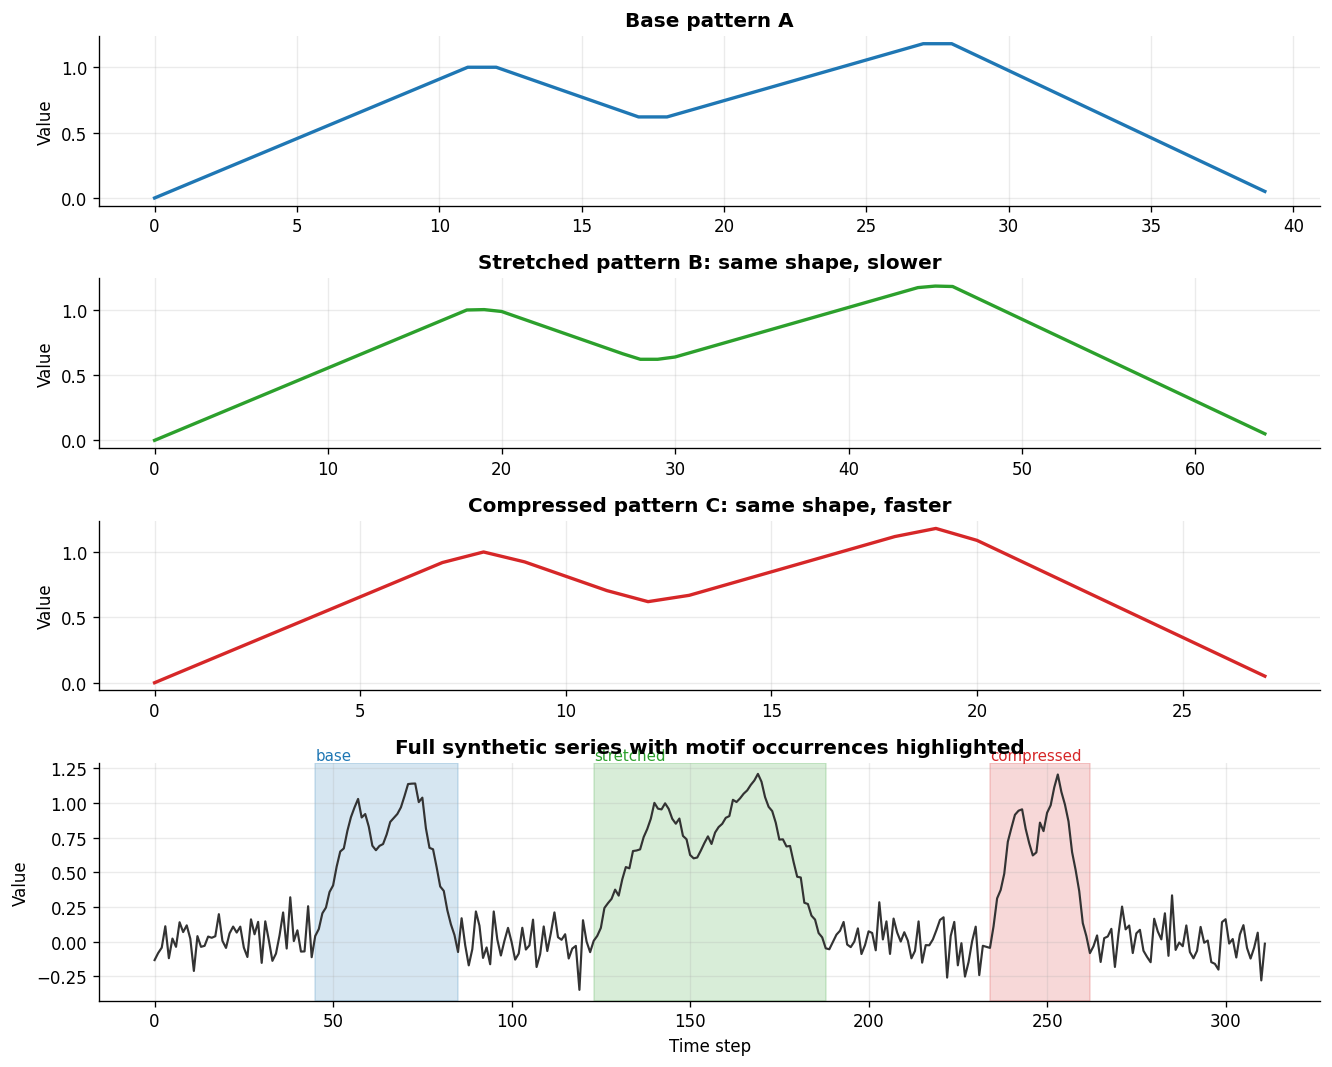

,name,start,length
0,base,45,40
1,stretched,123,65
2,compressed,234,28


In [3]:
rng = np.random.default_rng(20260520)

base_pattern = np.r_[
    np.linspace(0.00, 1.00, 12),
    np.linspace(1.00, 0.62, 6),
    np.linspace(0.62, 1.18, 10),
    np.linspace(1.18, 0.05, 12),
]
stretched_pattern = resize_pattern(base_pattern, 65)
compressed_pattern = resize_pattern(base_pattern, 28)

segment_a = rng.normal(0, 0.12, 45)
segment_b = rng.normal(0, 0.12, 38)
segment_c = rng.normal(0, 0.12, 46)
segment_d = rng.normal(0, 0.12, 50)

base_start = len(segment_a)
stretched_start = base_start + len(base_pattern) + len(segment_b)
compressed_start = stretched_start + len(stretched_pattern) + len(segment_c)

synthetic_series = np.r_[
    segment_a,
    base_pattern + rng.normal(0, 0.04, len(base_pattern)),
    segment_b,
    stretched_pattern + rng.normal(0, 0.04, len(stretched_pattern)),
    segment_c,
    compressed_pattern + rng.normal(0, 0.04, len(compressed_pattern)),
    segment_d,
]

motif_occurrences = pd.DataFrame([
    {"name": "base", "start": base_start, "length": len(base_pattern)},
    {"name": "stretched", "start": stretched_start, "length": len(stretched_pattern)},
    {"name": "compressed", "start": compressed_start, "length": len(compressed_pattern)},
])

fig, axes = plt.subplots(4, 1, figsize=(11, 9), gridspec_kw={"height_ratios": [1, 1, 1, 1.4]})
axes[0].plot(base_pattern, color="#1f77b4", linewidth=2)
axes[0].set_title("Base pattern A")
axes[0].set_ylabel("Value")

axes[1].plot(stretched_pattern, color="#2ca02c", linewidth=2)
axes[1].set_title("Stretched pattern B: same shape, slower")
axes[1].set_ylabel("Value")

axes[2].plot(compressed_pattern, color="#d62728", linewidth=2)
axes[2].set_title("Compressed pattern C: same shape, faster")
axes[2].set_ylabel("Value")

axes[3].plot(synthetic_series, color="#333333", linewidth=1.3)
colors = {"base": "#1f77b4", "stretched": "#2ca02c", "compressed": "#d62728"}
for row in motif_occurrences.itertuples(index=False):
    axes[3].axvspan(row.start, row.start + row.length, color=colors[row.name], alpha=0.18)
    axes[3].text(row.start, synthetic_series.max() + 0.10, row.name, color=colors[row.name], fontsize=9)
axes[3].set_title("Full synthetic series with motif occurrences highlighted")
axes[3].set_xlabel("Time step")
axes[3].set_ylabel("Value")

save_plot(fig, REPORT_DIR / "01_synthetic_variable_length_motifs.png")
plt.show()
plt.close(fig)

motif_occurrences


Matrix Profile requires a fixed window length `m`. If `m` is too short, longer occurrences are truncated. If `m` is too long, shorter occurrences are padded by unrelated surrounding behavior. LoCoMotif is relevant because it is designed for motif sets where occurrences can be time-warped versions of the same structure.


## 4. Simple fixed-length comparison intuition

The next cell compares windows extracted around each synthetic occurrence. The only thing that changes is the fixed window size. This shows why the choice of `m` can change the apparent similarity of the same underlying shape.


Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\01_fixed_length_overlay.png


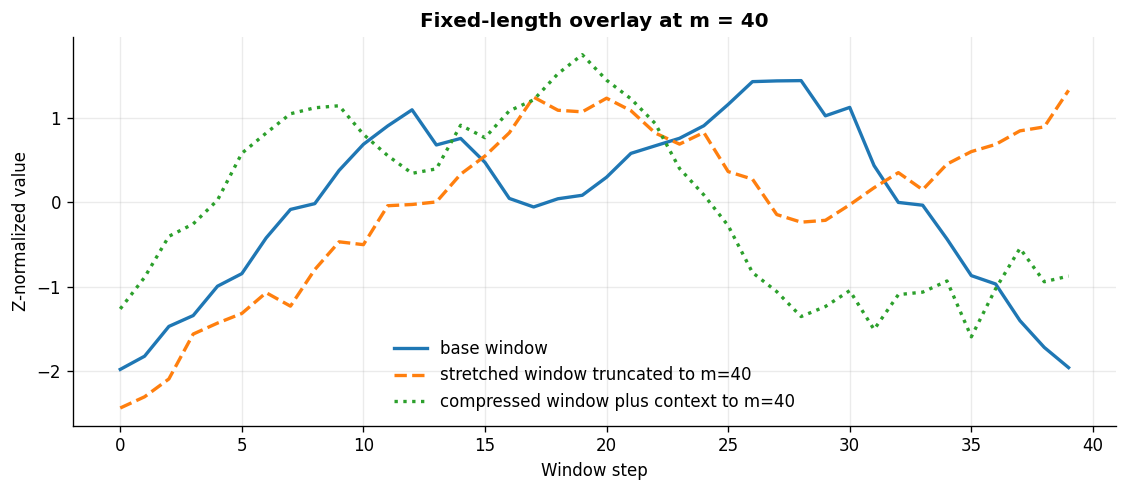

,window_length,comparison,distance,interpretation
0,28,base vs stretched,3.833163,stretched motif may be truncated when m is too...
1,28,base vs compressed,6.535904,compressed motif may include unrelated context...
2,40,base vs stretched,7.273282,stretched motif may be truncated when m is too...
3,40,base vs compressed,7.942808,compressed motif may include unrelated context...
4,65,base vs stretched,10.953966,stretched motif may be truncated when m is too...
5,65,base vs compressed,7.627847,compressed motif may include unrelated context...


In [4]:
def fixed_window(series, start, window_length):
    start = int(start)
    window_length = int(window_length)
    return np.asarray(series[start:start + window_length], dtype=float)


fixed_length_rows = []
for window_length in [28, 40, 65]:
    base_window = fixed_window(synthetic_series, base_start, window_length)
    stretched_window = fixed_window(synthetic_series, stretched_start, window_length)
    compressed_window = fixed_window(synthetic_series, compressed_start, window_length)

    comparisons = [
        ("base vs stretched", base_window, stretched_window, "stretched motif may be truncated when m is too short"),
        ("base vs compressed", base_window, compressed_window, "compressed motif may include unrelated context when m is too long"),
    ]
    for comparison, left, right, interpretation in comparisons:
        usable_length = min(len(left), len(right))
        distance = np.linalg.norm(
            z_normalize_array(left[:usable_length]) - z_normalize_array(right[:usable_length])
        )
        fixed_length_rows.append({
            "window_length": window_length,
            "comparison": comparison,
            "distance": float(distance),
            "interpretation": interpretation,
        })

fixed_length_comparison = pd.DataFrame(fixed_length_rows)
fixed_length_comparison.to_csv(REPORT_DIR / "01_fixed_length_comparison.csv", index=False)

overlay_length = len(base_pattern)
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(z_normalize_array(fixed_window(synthetic_series, base_start, overlay_length)), label="base window", linewidth=2)
ax.plot(z_normalize_array(fixed_window(synthetic_series, stretched_start, overlay_length)), label="stretched window truncated to m=40", linewidth=2, linestyle="--")
ax.plot(z_normalize_array(fixed_window(synthetic_series, compressed_start, overlay_length)), label="compressed window plus context to m=40", linewidth=2, linestyle=":")
ax.set_title("Fixed-length overlay at m = 40")
ax.set_xlabel("Window step")
ax.set_ylabel("Z-normalized value")
ax.legend(frameon=False)
save_plot(fig, REPORT_DIR / "01_fixed_length_overlay.png")
plt.show()
plt.close(fig)

fixed_length_comparison


## 5. Simple time-warping intuition

Dynamic Time Warping (DTW) is used here only as an intuition tool. LoCoMotif is not just DTW, but time-warping distance makes it clear why variable-speed motifs matter: two occurrences can have similar shape even if one unfolds faster than the other.


In [5]:
dtw_rows = []
for comparison, pattern in [
    ("base vs stretched", stretched_pattern),
    ("base vs compressed", compressed_pattern),
]:
    euclidean_after_resizing = np.linalg.norm(
        z_normalize_array(base_pattern) - z_normalize_array(resize_pattern(pattern, len(base_pattern)))
    )
    raw_dtw = dtw_distance(z_normalize_array(base_pattern), z_normalize_array(pattern))
    dtw_rows.append({
        "comparison": comparison,
        "euclidean_distance_after_resizing": float(euclidean_after_resizing),
        "dtw_distance": float(raw_dtw),
        "interpretation": "DTW compares the shape while allowing local speed changes.",
    })

synthetic_distance_comparison = pd.DataFrame(dtw_rows)
synthetic_distance_comparison.to_csv(REPORT_DIR / "synthetic_distance_comparison.csv", index=False)
synthetic_distance_comparison


,comparison,euclidean_distance_after_resizing,dtw_distance,interpretation
0,base vs stretched,0.050023,0.601089,DTW compares the shape while allowing local sp...
1,base vs compressed,0.182172,0.631029,DTW compares the shape while allowing local sp...


## 6. Real financial example: BTCUSDT 1-hour features

The first real-data example uses BTCUSDT 1-hour features from 2021-01-01 through 2021-06-30. One-hour data is a practical first step because it is smoother than one-minute data, still intraday, computationally feasible, and suitable for initial HMM and LoCoMotif testing.


Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\01_btc_1h_sample_close.png


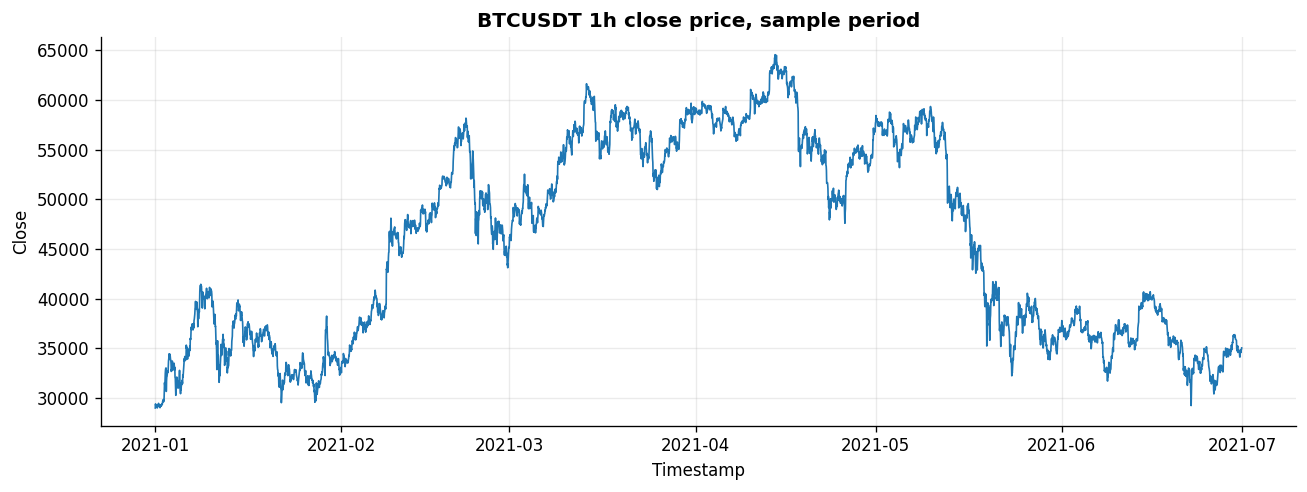

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\01_btc_1h_sample_log_return.png


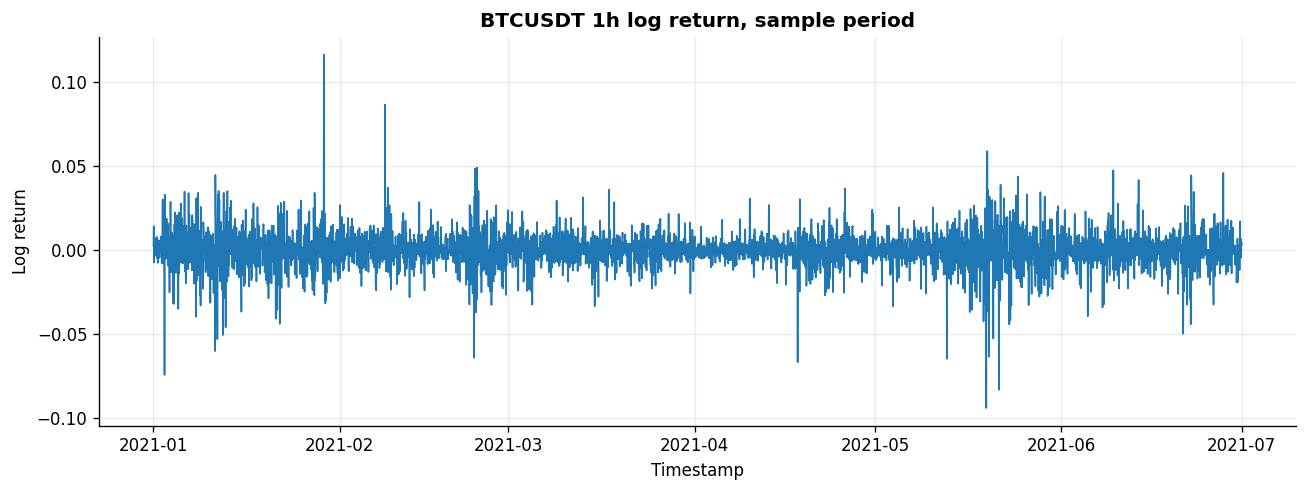

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\01_btc_1h_sample_volatility.png


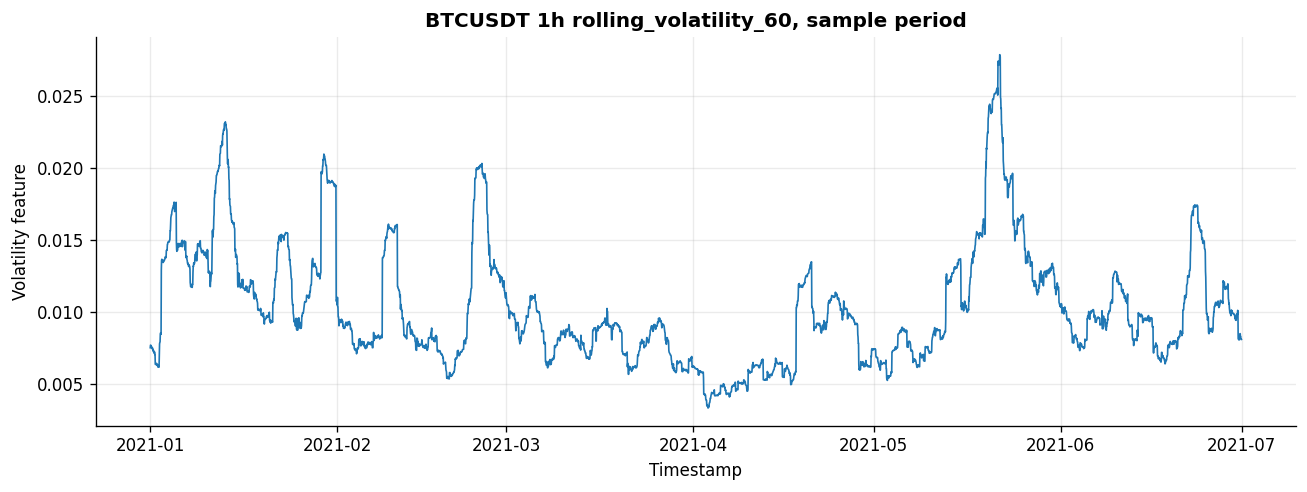

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\01_btc_1h_sample_volume_zscore.png


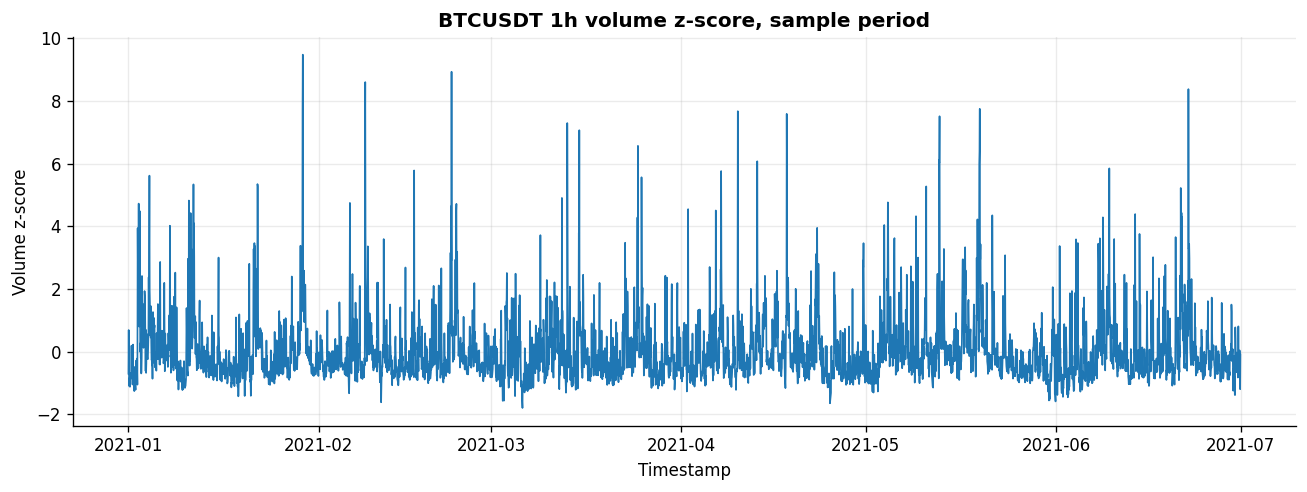

,asset,rows,start,end,selected_features_available,missing_pct
0,BTCUSDT,4337,2021-01-01T00:00:00+00:00,2021-06-30T23:00:00+00:00,"log_return, rolling_volatility_60, hl_range, v...",0.0


In [6]:
btc_1h_path = FINAL_DATASET_DIR / "features" / "crypto" / "BTCUSDT_1h_features_2020_2025.parquet"
btc_1h = load_parquet_with_timestamp(btc_1h_path)

sample_start = pd.Timestamp("2021-01-01", tz="UTC")
sample_end = pd.Timestamp("2021-06-30 23:59:59", tz="UTC")
btc_sample = btc_1h.loc[
    (btc_1h["timestamp"] >= sample_start) & (btc_1h["timestamp"] <= sample_end)
].copy()

if btc_sample.empty:
    fallback_start = btc_1h["timestamp"].min()
    fallback_end = fallback_start + pd.DateOffset(months=6)
    btc_sample = btc_1h.loc[
        (btc_1h["timestamp"] >= fallback_start) & (btc_1h["timestamp"] < fallback_end)
    ].copy()
    warnings.warn("Requested 2021 H1 sample was not available. Using the first six months in the file.")

volatility_selection, volatility_replacements, volatility_missing = select_existing_features(
    btc_sample, ["rolling_volatility_60"]
)
volatility_column = volatility_selection[0] if volatility_selection else None

def plot_financial_column(df, column, title, ylabel, filename):
    if column is None or column not in df.columns:
        warnings.warn(f"Skipping plot because column {column!r} is unavailable.")
        return None
    fig, ax = plt.subplots(figsize=(11, 4.2))
    ax.plot(df["timestamp"], df[column], linewidth=1.0, color="#1f77b4")
    ax.set_title(title)
    ax.set_xlabel("Timestamp")
    ax.set_ylabel(ylabel)
    path = save_plot(fig, REPORT_DIR / filename)
    plt.show()
    plt.close(fig)
    return path

plot_financial_column(btc_sample, "close", "BTCUSDT 1h close price, sample period", "Close", "01_btc_1h_sample_close.png")
plot_financial_column(btc_sample, "log_return", "BTCUSDT 1h log return, sample period", "Log return", "01_btc_1h_sample_log_return.png")
plot_financial_column(btc_sample, volatility_column, f"BTCUSDT 1h {volatility_column}, sample period", "Volatility feature", "01_btc_1h_sample_volatility.png")
plot_financial_column(btc_sample, "volume_zscore", "BTCUSDT 1h volume z-score, sample period", "Volume z-score", "01_btc_1h_sample_volume_zscore.png")

pd.DataFrame([summarize_dataframe(btc_sample, "BTCUSDT", ["log_return", volatility_column, "hl_range", "volume_zscore"])])


## 7. Candidate input representations for LoCoMotif

LoCoMotif can be discussed using several input representations. The thesis benchmark should keep these representations explicit so that interpretability and stability are compared fairly.


In [7]:
representation_table = pd.DataFrame([
    {
        "Representation": "Univariate close or log_return",
        "Columns": "close or log_return",
        "Use case": "Simple visual intuition and direct comparison with univariate Matrix Profile",
        "Expected strength": "Easy to explain and fast to run",
        "Expected weakness": "Can miss volatility/range/volume context",
    },
    {
        "Representation": "Multivariate returns + volatility",
        "Columns": f"log_return, {volatility_column}",
        "Use case": "Core nonstationarity-aware motif search",
        "Expected strength": "Captures direction and regime intensity",
        "Expected weakness": "Still ignores range and volume activity",
    },
    {
        "Representation": "Multivariate returns + volatility + range + volume activity",
        "Columns": f"log_return, {volatility_column}, hl_range, volume_zscore",
        "Use case": "Recommended initial thesis representation",
        "Expected strength": "Balances price movement, volatility, intrabar range, and activity",
        "Expected weakness": "Requires careful scaling and missing-value handling",
    },
])
representation_table.to_csv(REPORT_DIR / "01_candidate_input_representations.csv", index=False)
representation_table


,Representation,Columns,Use case,Expected strength,Expected weakness
0,Univariate close or log_return,close or log_return,Simple visual intuition and direct comparison ...,Easy to explain and fast to run,Can miss volatility/range/volume context
1,Multivariate returns + volatility,"log_return, rolling_volatility_60",Core nonstationarity-aware motif search,Captures direction and regime intensity,Still ignores range and volume activity
2,Multivariate returns + volatility + range + vo...,"log_return, rolling_volatility_60, hl_range, v...",Recommended initial thesis representation,"Balances price movement, volatility, intrabar ...",Requires careful scaling and missing-value han...


## 8. Visualizing multivariate channels

LoCoMotif should operate on comparable scaled channels because raw feature magnitudes differ. The next cell z-normalizes the selected feature columns and plots both separate channels and a combined offset view.


Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\01_btc_channel_log_return.png


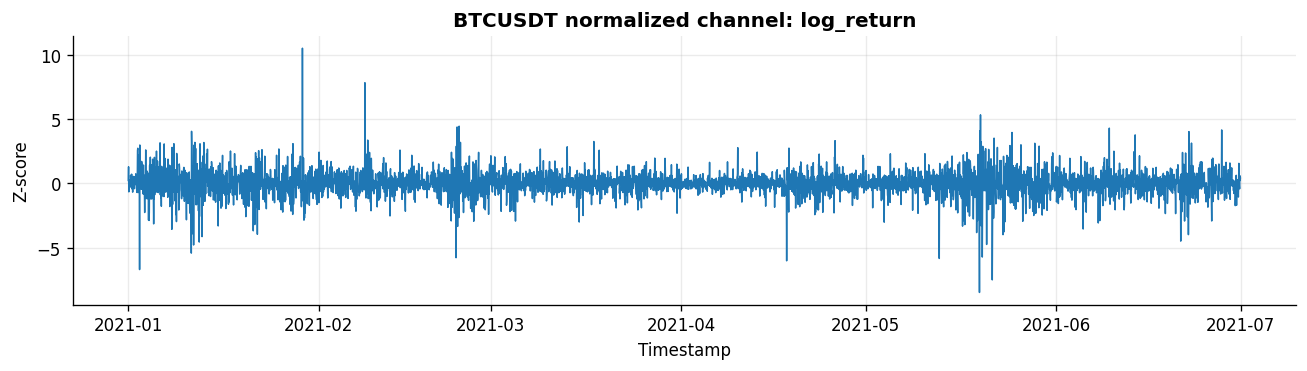

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\01_btc_channel_rolling_volatility_60.png


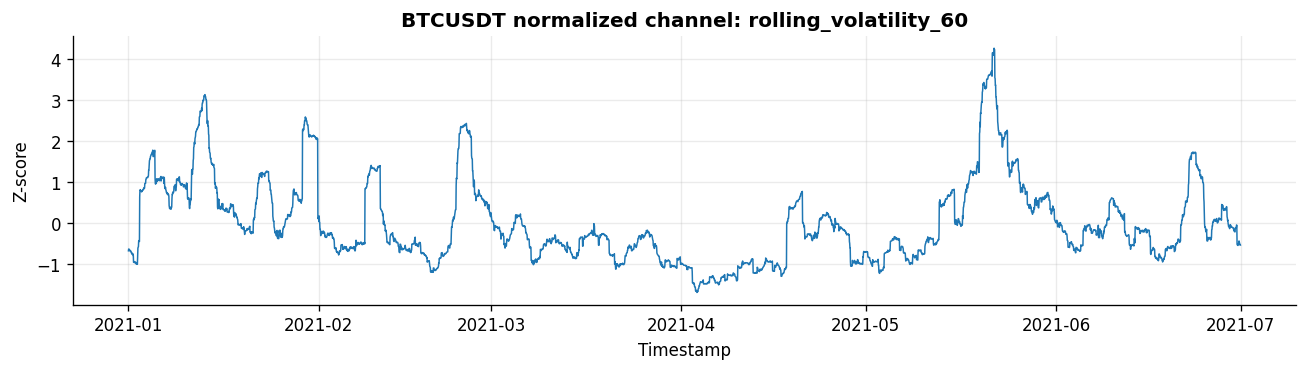

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\01_btc_channel_hl_range.png


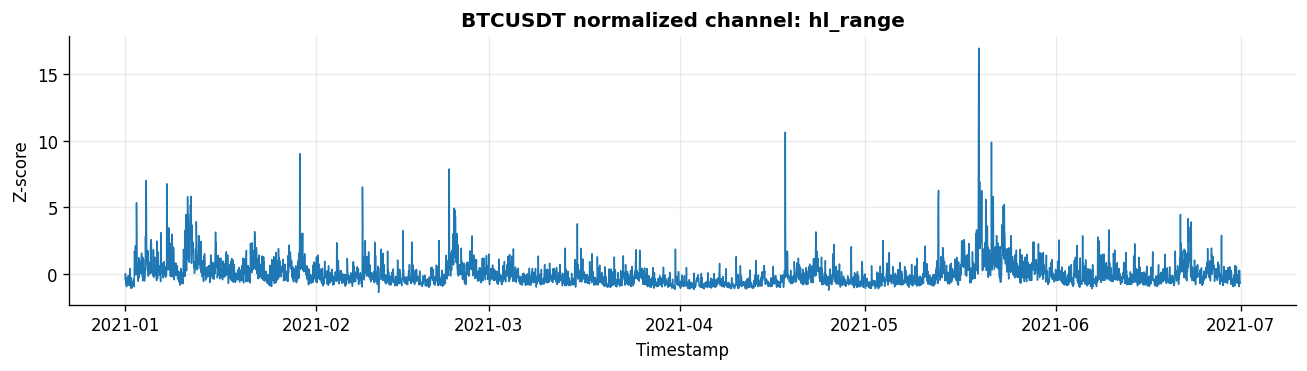

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\01_btc_channel_volume_zscore.png


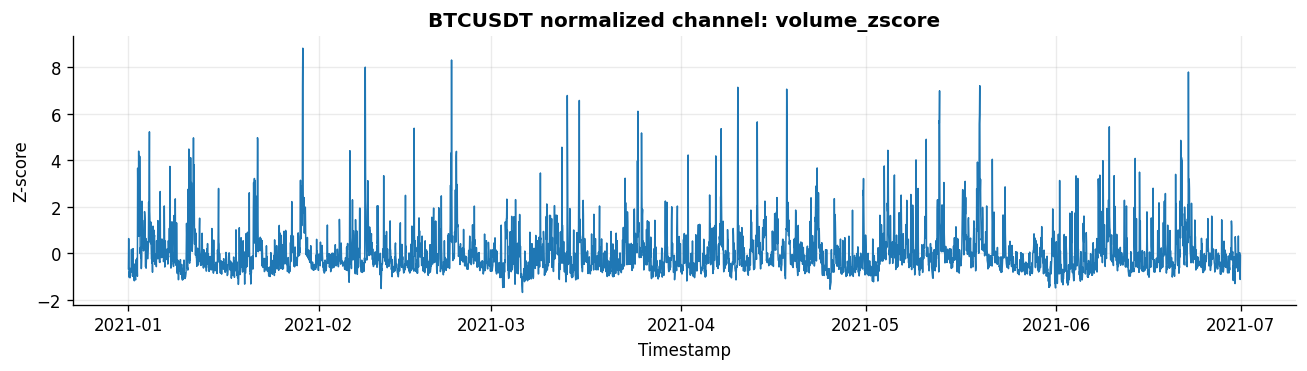

Saved figure: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\locomotif_initial_study\01_btc_multichannel_normalized_features.png


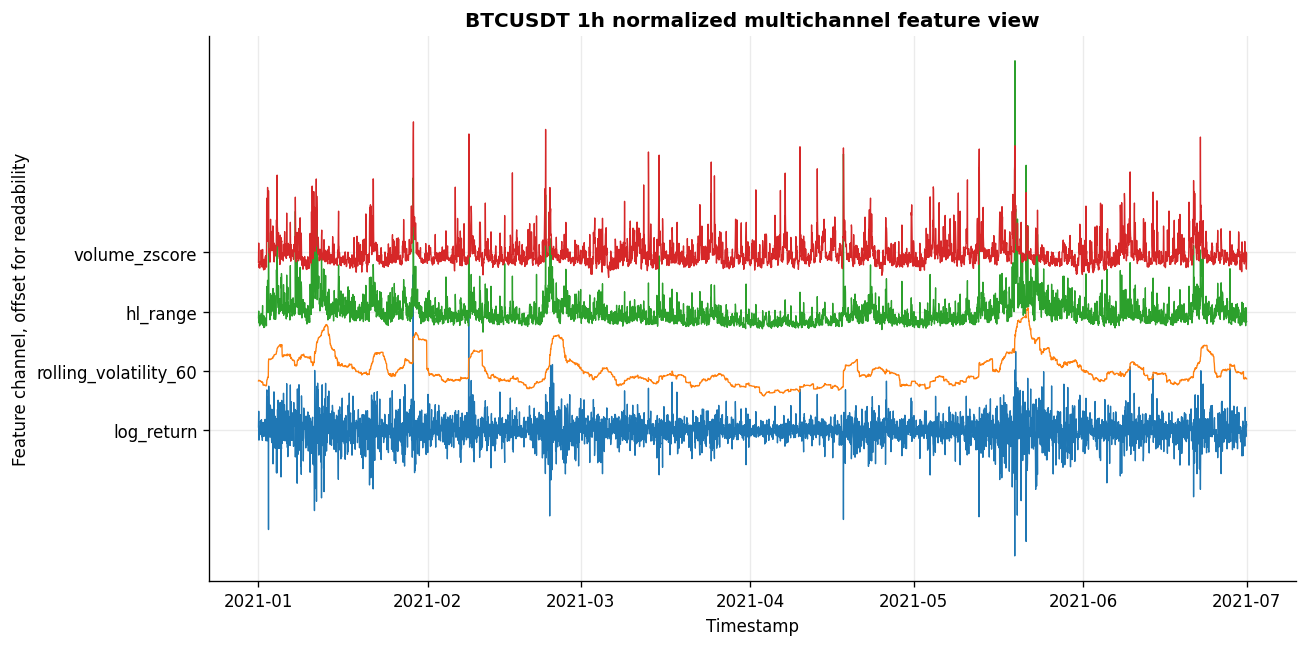

,mean,std
log_return,0.000044,0.011063
rolling_volatility_60,0.010291,0.004114
hl_range,0.016793,0.012177
volume_zscore,0.012901,1.073593


In [8]:
requested_locomotif_features = ["log_return", "rolling_volatility_60", "hl_range", "volume_zscore"]
selected_locomotif_features, feature_replacements, missing_features = select_existing_features(
    btc_sample, requested_locomotif_features
)

btc_feature_frame = btc_sample.replace([np.inf, -np.inf], np.nan).dropna(
    subset=selected_locomotif_features
).copy()
btc_z_features, btc_z_stats = zscore_dataframe(btc_feature_frame, selected_locomotif_features)

for feature in selected_locomotif_features:
    fig, ax = plt.subplots(figsize=(11, 3.2))
    ax.plot(btc_feature_frame["timestamp"], btc_z_features[feature], linewidth=0.9)
    ax.set_title(f"BTCUSDT normalized channel: {feature}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Z-score")
    save_plot(fig, REPORT_DIR / f"01_btc_channel_{feature}.png")
    plt.show()
    plt.close(fig)

fig, ax = plt.subplots(figsize=(11, 5.5))
offsets = np.arange(len(selected_locomotif_features), dtype=float) * 4.0
for offset, feature in zip(offsets, selected_locomotif_features):
    ax.plot(btc_feature_frame["timestamp"], btc_z_features[feature] + offset, linewidth=0.8)
ax.set_yticks(offsets)
ax.set_yticklabels(selected_locomotif_features)
ax.set_title("BTCUSDT 1h normalized multichannel feature view")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Feature channel, offset for readability")
save_plot(fig, REPORT_DIR / "01_btc_multichannel_normalized_features.png")
plt.show()
plt.close(fig)

btc_z_stats


## 9. LoCoMotif availability and expected API placeholder

This notebook intentionally focuses on concept and data preparation. The next notebook uses the prepared representation to run Matrix Profile baselines and to connect a LoCoMotif adapter when the package API is available.


In [9]:
if LOCOMOTIF_AVAILABLE:
    public_callables = sorted(
        name for name, obj in inspect.getmembers(LOCOMOTIF_MODULE) if callable(obj) and not name.startswith("_")
    )
    print(f"Detected LoCoMotif module: {LOCOMOTIF_MODULE_NAME}")
    print("Public callables found in the module:")
    print(public_callables[:30])
else:
    print("LoCoMotif is not installed in this environment.")
    print("Action note: connect the real LoCoMotif package in the adapter cell of notebook 02.")
    print("Prepared input shape for BTC sample:", btc_z_features[selected_locomotif_features].shape)
    print("Expected orientation for most motif packages: time x channels.")


Detected LoCoMotif module: locomotif.locomotif
Public callables found in the module:
['List', 'LoCoMotif', 'Path', 'SortedPathArray', 'apply_locomotif', 'boolean', 'float32', 'get_locomotif_instance', 'int32', 'jitclass', 'njit', 'project_to_vertical_axis']


## 10. Final intuition summary

LoCoMotif is relevant because financial motifs may recur with varying duration and speed across regimes. Matrix Profile provides a strong fixed-length baseline, while LoCoMotif tests whether time-warped motif sets are more stable or interpretable under nonstationarity.


In [10]:
summary_01 = {
    "notebook": "01_locomotif_basics_with_visual_intuition",
    "thesis_context": "Regime-conditioned multivariate motif discovery under nonstationarity",
    "default_asset": "BTCUSDT",
    "default_frequency": "1h",
    "sample_start": pd.Timestamp(btc_sample["timestamp"].min()).isoformat(),
    "sample_end": pd.Timestamp(btc_sample["timestamp"].max()).isoformat(),
    "selected_features": selected_locomotif_features,
    "feature_replacements": feature_replacements,
    "stumpy_available": STUMPY_AVAILABLE,
    "locomotif_available": LOCOMOTIF_AVAILABLE,
    "key_takeaway": (
        "Fixed-length motif baselines are interpretable, but financial motifs may recur "
        "with variable length and local speed changes across regimes."
    ),
}
with open(REPORT_DIR / "01_locomotif_basics_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_01, f, indent=2)

summary_01


{'notebook': '01_locomotif_basics_with_visual_intuition',
 'thesis_context': 'Regime-conditioned multivariate motif discovery under nonstationarity',
 'default_asset': 'BTCUSDT',
 'default_frequency': '1h',
 'sample_start': '2021-01-01T00:00:00+00:00',
 'sample_end': '2021-06-30T23:00:00+00:00',
 'selected_features': ['log_return',
  'rolling_volatility_60',
  'hl_range',
  'volume_zscore'],
 'feature_replacements': {},
 'stumpy_available': True,
 'locomotif_available': True,
 'key_takeaway': 'Fixed-length motif baselines are interpretable, but financial motifs may recur with variable length and local speed changes across regimes.'}